In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline,make_pipeline
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel as C,DotProduct, RationalQuadratic
from sklearn.neural_network import MLPRegressor
import shap
import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/ML_PU/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 初始准备工作
# 1.读取清洗好的数据
file_path = "Final_Features_Ultimate_all_deletion.csv" 
df = pd.read_csv(file_path)

In [5]:
# 2. 定义特征组 (严格对齐训练笔记本 alghorithm_multi_1.9_tensile.ipynb 中的 features_mech_all)
# ⚠️ 注意：训练时已删除 Add_Crosslinker_Flag 和 Extender_Class（与 X5 完全相关 r=1.0）

# A. 力学特征组 (用于预测 Strength, Elongation) — 共 14 个特征
features_mech = [
    # --- 1. 用量层 (Dosage) ---
    'X1_Soft_Content',      # 软段含量
    'X2_DA_Content',        # DA单体含量
    'X3_Hard_Content',      # 硬段含量
    'X4_R_Ratio',           # 异氰酸酯指数
    'X5_Add_Crosslink',     # 额外非DA交联剂含量
    
    # --- 2. 身份层 (Identity) ---
    'DA_Linker_Type',       # 0=无, 1=糠胺, 2=糠醇
    'Network_Topology',     # 0=主链, 1=侧链
    'Polyol_Class',         # 0=聚醚, 1=聚酯
    'Iso_Class',            # 0=脂肪族, 1=芳香族
    
    # --- 3. 机理层 (Mechanism) ---
    'Soft_Mw',              # 软段分子量
    'Constraint_Factor',    # 冻结因子 (关键!)
    'Hard_Symmetry',        # 硬段对称性
    'Soft_Cryst',           # 软段结晶性
    'Synergy_Feature'       # 结晶协同因子
    # ❌ 已删除: Add_Crosslinker_Flag (与 X5 r=1.0)
    # ❌ 已删除: Extender_Class (与 X5 完全相关)
]

# B. 愈合特征组 (用于预测 Healing Efficiency)
features_heal = features_mech + ['healing_temperature', 'healing_time']

print(f"✅ 特征组定义完毕 (与训练笔记本严格对齐)")
print(f"   力学模型特征数: {len(features_mech)} (应为 14)")
print(f"   自愈合模型特征数: {len(features_heal)} (应为 16)")

# 3. 二次清洗
def get_clean_data(target_col, feature_cols, df):
    missing_cols = [c for c in feature_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"以下特征在 CSV 中找不到: {missing_cols}")
    data = df.dropna(subset=[target_col] + feature_cols).copy()
    X = data[feature_cols].values
    y = data[target_col].values
    return X, y

# 4. 评估函数
def evaluate_model(model, X, y, task_name="Task"):
    cv = LeaveOneOut()
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, rmse, y_pred

✅ 特征组定义完毕 (与训练笔记本严格对齐)
   力学模型特征数: 14 (应为 14)
   自愈合模型特征数: 16 (应为 16)


In [6]:
import pandas as pd
import numpy as np
import itertools

def generate_virtual_library_ultimate():
    """
    修复版虚拟配方库生成器
    修复点:
    1. 删除 Extender_Class 排列 (模型不使用)
    2. Soft_Mw 上限限制在 2000 (训练集范围)
    3. Constraint_Factor 四舍五入到 0.0001 精度 (与训练集对齐)
    4. DA_Linker_Type 包含 0 (无DA键, 仅作对照组)
    5. 删除 Add_Crosslinker_Flag (模型不使用)
    """
    print("正在生成虚拟配方库 (修复版, 对齐训练集特征) ...")

    # === 1. 原材料基因库 ===
    
    # A. 软段: [名称, Polyol_Class, Soft_Mw, Soft_Cryst]
    # ⚠️ Soft_Mw 限制在训练集范围 [1000, 2000]
    soft_segments = [
        ('PTMG1000', 0, 1000, 1),  # 聚醚, 结晶
        ('PTMG2000', 0, 2000, 1),
        ('PPG1000',  0, 1000, 0),  # 聚醚, 不结晶
        ('PPG2000',  0, 2000, 0),
        ('PCL1000',  1, 1000, 1),  # 聚酯, 结晶
        ('PCL2000',  1, 2000, 1),
        ('PBA1000',  1, 1000, 1),  # 聚酯, 结晶
        ('PBA2000',  1, 2000, 1),
    ]

    # B. 硬段: [名称, Iso_Class, Hard_Symmetry]
    hard_segments = [
        ('IPDI', 0, 0),  # 脂肪族, 不对称
        ('MDI',  1, 1),  # 芳香族, 对称
        ('HDI',  0, 1),  # 脂肪族, 对称
        ('TDI',  1, 0),  # 芳香族, 不对称
    ]

    # C. 连续变量网格 (范围对齐训练集)
    X1_range = np.linspace(0.35, 0.77, 9)   # 训练集 0.32~0.77
    X2_range = np.linspace(0.05, 0.40, 8)   # 训练集 0.00~0.44
    X4_range = [0.95, 1.00, 1.05, 1.10]     # 训练集 0.30~1.43, 实际常用范围
    X5_range = [0.0, 0.02]                   # 训练集 0.00~0.033

    # D. 离散变量
    da_types = [1, 2]       # 1=糠胺(KA), 2=糠醇(KC); 0=无DA不在主循环
    topologies = [0, 1]     # 0=主链, 1=侧链

    virtual_data = []

    combinations = itertools.product(
        soft_segments, hard_segments, da_types, topologies,
        X1_range, X2_range, X4_range, X5_range
    )

    for combo in combinations:
        (soft, hard, da_type, topo, x1, x2, x4, x5) = combo
        s_name, s_class, s_mw, s_cryst = soft
        h_name, h_iso_class, h_sym = hard
        
        # 质量守恒
        x3 = 1.0 - x1 - x2 - x5
        if x3 < 0.10 or x3 > 0.60:
            continue
        
        row = {}
        # 1. 用量层
        row['X1_Soft_Content'] = round(x1, 4)
        row['X2_DA_Content'] = round(x2, 4)
        row['X3_Hard_Content'] = round(x3, 4)
        row['X4_R_Ratio'] = x4
        row['X5_Add_Crosslink'] = x5
        
        # 2. 身份层 (仅保留模型使用的 4 个)
        row['DA_Linker_Type'] = da_type
        row['Network_Topology'] = topo
        row['Polyol_Class'] = s_class
        row['Iso_Class'] = h_iso_class
        
        # 3. 机理层
        row['Soft_Mw'] = s_mw
        # ⚠️ Constraint_Factor 四舍五入到 0.0001, 与训练集对齐
        row['Constraint_Factor'] = round(x3 / s_mw, 4)
        row['Hard_Symmetry'] = h_sym
        row['Soft_Cryst'] = s_cryst
        row['Synergy_Feature'] = round(x1 * s_cryst * h_sym, 4)
        
        # 辅助信息
        da_str = "KA" if da_type == 1 else "KC"
        topo_str = "Main" if topo == 0 else "Side"
        row['Recipe_Name'] = f"{s_name}_{h_name}_{da_str}({topo_str})_X1={x1:.2f}_X2={x2:.2f}"
        
        # 工艺参数 (愈合预测时需要)
        row['healing_temperature'] = 60
        row['healing_time'] = 24
        
        virtual_data.append(row)

    df_virtual = pd.DataFrame(virtual_data)
    return df_virtual

# 执行生成
df_virtual_lib = generate_virtual_library_ultimate()
print(f"✅ 虚拟配方库生成完毕，共 {len(df_virtual_lib)} 条")
print(f"   特征列: {[c for c in df_virtual_lib.columns if c not in ['Recipe_Name','healing_temperature','healing_time']]}")
print(f"   Soft_Mw 范围: {df_virtual_lib['Soft_Mw'].unique()}")
print(f"   Constraint_Factor 范围: [{df_virtual_lib['Constraint_Factor'].min():.4f}, {df_virtual_lib['Constraint_Factor'].max():.4f}]")

正在生成虚拟配方库 (修复版, 对齐训练集特征) ...
✅ 虚拟配方库生成完毕，共 52224 条
   特征列: ['X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink', 'DA_Linker_Type', 'Network_Topology', 'Polyol_Class', 'Iso_Class', 'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature']
   Soft_Mw 范围: [1000 2000]
   Constraint_Factor 范围: [0.0001, 0.0006]


In [7]:
# ============================================
# 模型 1: 拉伸强度 (tensile_strength) — SVR (RBF)
# ============================================
target_col = 'tensile_strength'
X, y = get_clean_data(target_col, features_mech, df)

param_grid = {
    'svr__C': [1, 10, 50, 100, 500, 1000],
    'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
    'svr__epsilon': [0.01, 0.1, 0.5]
}

pipe = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
grid_search = GridSearchCV(pipe, param_grid, cv=LeaveOneOut(),
                           scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X, y)

best_svr_tensile = grid_search.best_estimator_
print(f"\n[Tensile - SVR 最佳参数] {grid_search.best_params_}")

# 全量拟合
data_str = df.dropna(subset=['tensile_strength'] + features_mech).copy()
X_str = data_str[features_mech]
y_str = data_str['tensile_strength']
best_svr_tensile.fit(X_str, y_str)
print(f"✅ 强度模型训练完成 (SVR)。有效样本数：{len(X_str)}")

r2, rmse, _ = evaluate_model(best_svr_tensile, X_str.values, y_str.values, "Strength")
print(f"   Strength LOOCV | R²={r2:.3f}, RMSE={rmse:.2f}")

Fitting 84 folds for each of 108 candidates, totalling 9072 fits

[Tensile - SVR 最佳参数] {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}
✅ 强度模型训练完成 (SVR)。有效样本数：84
   Strength LOOCV | R²=0.765, RMSE=6.52


In [8]:
# ============================================
# 模型 2: 断裂伸长率 (elongation) — XGBoost
# ⚠️ 训练笔记本最优模型是 XGBoost，不是 SVR！
# ============================================
from xgboost import XGBRegressor

target_col = 'elongation'
X, y = get_clean_data(target_col, features_mech, df)

param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0]
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)
random_search = RandomizedSearchCV(
    xgb_base, param_grid_xgb, n_iter=200,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error', n_jobs=-1, verbose=1, random_state=42
)
random_search.fit(X, y)

best_xgb_elongation = random_search.best_estimator_
print(f"\n[Elongation - XGBoost 最佳参数] {random_search.best_params_}")

# 全量拟合
data_elo = df.dropna(subset=['elongation'] + features_mech).copy()
X_elo = data_elo[features_mech]
y_elo = data_elo['elongation']
best_xgb_elongation.fit(X_elo, y_elo)
print(f"✅ 伸长率模型训练完成 (XGBoost)。有效样本数: {len(X_elo)}")

r2, rmse, _ = evaluate_model(best_xgb_elongation, X_elo.values, y_elo.values, "Elongation")
print(f"   Elongation LOOCV | R²={r2:.3f}, RMSE={rmse:.2f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

[Elongation - XGBoost 最佳参数] {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
✅ 伸长率模型训练完成 (XGBoost)。有效样本数: 84
   Elongation LOOCV | R²=0.668, RMSE=155.47


In [9]:
# ============================================
# 模型 3: 自愈合效率 (healing_eff) — GPR (Gaussian Process)
# ⚠️ 训练笔记本最优模型是 GPR，不是 SVR！
# ============================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel as C

target_col = 'healing_eff'
X, y = get_clean_data(target_col, features_heal, df)

# GPR 需要标准化 + 核函数组合搜索
from sklearn.pipeline import make_pipeline

# 定义多组核函数候选
kernel_candidates = [
    C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
    C(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0),
    C(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1.0),
    C(1.0) * RBF(length_scale=1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1.0),
]

best_r2 = -np.inf
best_gpr_healing = None

for ki, kernel in enumerate(kernel_candidates):
    pipe_gpr = make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10, random_state=42)
    )
    try:
        r2_k, rmse_k, _ = evaluate_model(pipe_gpr, X, y, f"GPR-kernel{ki}")
        print(f"  Kernel {ki}: R²={r2_k:.3f}, RMSE={rmse_k:.2f}")
        if r2_k > best_r2:
            best_r2 = r2_k
            best_gpr_healing = pipe_gpr
    except Exception as e:
        print(f"  Kernel {ki} failed: {e}")

# 全量拟合
data_heal = df.dropna(subset=['healing_eff'] + features_heal).copy()
X_heal = data_heal[features_heal]
y_heal = data_heal['healing_eff']
best_gpr_healing.fit(X_heal, y_heal)
print(f"\n✅ 自愈合模型训练完成 (GPR)。有效样本数: {len(X_heal)}")

r2, rmse, _ = evaluate_model(best_gpr_healing, X_heal.values, y_heal.values, "Healing")
print(f"   Healing LOOCV | R²={r2:.3f}, RMSE={rmse:.2f}")

  Kernel 0: R²=0.759, RMSE=5.94
  Kernel 1: R²=0.801, RMSE=5.39
  Kernel 2: R²=0.768, RMSE=5.82
  Kernel 3: R²=0.768, RMSE=5.82

✅ 自愈合模型训练完成 (GPR)。有效样本数: 37
   Healing LOOCV | R²=0.801, RMSE=5.39


In [10]:
# ============================================
# 预测与筛选 (对齐修复后的 14/16 特征 + 正确模型)
# ============================================

# A. 预测特征列表 (与训练时 features_mech 严格一致, 14个)
features_mech_pred = [
    'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink',
    'DA_Linker_Type', 'Network_Topology', 'Polyol_Class', 'Iso_Class',
    'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature'
]
features_heal_pred = features_mech_pred + ['healing_temperature', 'healing_time']

# B. 对齐检查
assert features_mech_pred == features_mech, f"❌ 特征列表不一致!"
print(f"✅ 特征列表检查通过: 力学={len(features_mech_pred)}个, 愈合={len(features_heal_pred)}个")

# C. 准备预测数据
if 'healing_temperature' not in df_virtual_lib.columns:
    df_virtual_lib['healing_temperature'] = 60.0
if 'healing_time' not in df_virtual_lib.columns:
    df_virtual_lib['healing_time'] = 24.0

X_input_mech = df_virtual_lib[features_mech_pred]
X_input_heal = df_virtual_lib[features_heal_pred]

# D. 执行预测 (使用正确的最优模型)
print(f"正在对 {len(df_virtual_lib)} 个虚拟配方进行全量预测...")

# 强度 → SVR
df_virtual_lib['Pred_Strength'] = best_svr_tensile.predict(X_input_mech)

# 伸长率 → XGBoost (不是SVR!)
df_virtual_lib['Pred_Elongation'] = best_xgb_elongation.predict(X_input_mech)

# 自愈合 → GPR (不是SVR!)
df_virtual_lib['Pred_Healing'] = best_gpr_healing.predict(X_input_heal)

print("✅ 预测完成！\n")

# === 统计概览 ===
print("=== 预测值统计概览 ===")
print(df_virtual_lib[['Pred_Strength', 'Pred_Healing', 'Pred_Elongation']].describe().round(2))

# 极值检查
cols_debug = ['Recipe_Name', 'Pred_Strength', 'Pred_Healing', 'Pred_Elongation']
print("\n=== 最强配方 Top 3 ===")
print(df_virtual_lib.sort_values(by='Pred_Strength', ascending=False)[cols_debug].head(3).to_string(index=False))
print("\n=== 最易愈合配方 Top 3 ===")
print(df_virtual_lib.sort_values(by='Pred_Healing', ascending=False)[cols_debug].head(3).to_string(index=False))

# === 筛选 ===
target_A = df_virtual_lib[
    (df_virtual_lib['Pred_Strength'] > 30) &
    (df_virtual_lib['Pred_Strength'] < 35) &
    (df_virtual_lib['Pred_Healing'] < 65) &
    (df_virtual_lib['Pred_Elongation'] > 50)
].sort_values(by='Pred_Strength', ascending=False)

target_B = df_virtual_lib[
    (df_virtual_lib['Pred_Healing'] > 80) &
    (df_virtual_lib['Pred_Healing'] < 95) &
    (df_virtual_lib['Pred_Strength'] > 5) &
    (df_virtual_lib['Pred_Strength'] < 20)
].sort_values(by='Pred_Healing', ascending=False)

cols_to_show = ['Recipe_Name', 'X1_Soft_Content', 'X3_Hard_Content', 'Soft_Mw',
                'Constraint_Factor', 'Pred_Strength', 'Pred_Healing', 'Pred_Elongation']

print(f"\n====== Target A: 刚性锚点 (Top 20) ======  [共 {len(target_A)} 条]")
if len(target_A) > 0:
    print(target_A[cols_to_show].head(20).to_string(index=False))
else:
    print("未找到满足条件的配方，建议放宽阈值。")

print(f"\n====== Target B: 动态流体 (Top 20) ======  [共 {len(target_B)} 条]")
if len(target_B) > 0:
    print(target_B[cols_to_show].head(20).to_string(index=False))
else:
    print("未找到满足条件的配方，建议放宽阈值。")

target_A.head(25).to_csv('Target_A_Recipes_New.csv', index=False)
target_B.head(25).to_csv('Target_B_Recipes_New.csv', index=False)
print("\n配方已保存至 Target_A_Recipes_New.csv 和 Target_B_Recipes_New.csv")

✅ 特征列表检查通过: 力学=14个, 愈合=16个
正在对 52224 个虚拟配方进行全量预测...
✅ 预测完成！

=== 预测值统计概览 ===
       Pred_Strength  Pred_Healing  Pred_Elongation
count       52224.00      52224.00         52224.00
mean           21.63         81.41           543.64
std            11.78          8.19           207.39
min           -16.24         49.29           131.59
25%            13.34         76.20           369.18
50%            21.53         81.84           549.36
75%            29.77         87.22           717.66
max            58.31        102.01          1079.09

=== 最强配方 Top 3 ===
                          Recipe_Name  Pred_Strength  Pred_Healing  Pred_Elongation
PTMG2000_MDI_KA(Main)_X1=0.35_X2=0.05      58.306014     73.905449       734.090881
PTMG2000_MDI_KA(Main)_X1=0.35_X2=0.05      57.957502     73.995512       742.858765
PTMG2000_MDI_KC(Main)_X1=0.35_X2=0.05      57.853175     68.938857       733.794006

=== 最易愈合配方 Top 3 ===
                          Recipe_Name  Pred_Strength  Pred_Healing  Pred_Elon

In [11]:
# ============================================
# 🧪 简易验证配方设计 — 快速合成验证模型准确性
# ============================================
"""
设计原则:
1. 配方简单: 仅一种软段 + 一种硬段 + 一种DA键
2. 性能中规中矩: tensile ~10-20 MPa, elongation ~300-600%, healing ~60-90%
3. 体系干净: 无额外死交联 (X5=0), 无扩链剂干扰
4. 全部落在训练集分布内 (无外推风险)
5. 覆盖不同软段/硬段组合, 便于交叉验证
"""
import pandas as pd
import numpy as np

print("="*80)
print("🧪 简易验证配方设计 (Quick Validation Recipes)")
print("="*80)

# 定义候选验证配方 (手动精选, 基于训练集常见区间)
validation_recipes = [
    {
        'name': 'V1-PTMG2000-IPDI-KA(主链)',
        'description': '经典聚醚体系, 脂肪族不对称硬段, 糠胺DA键在主链',
        'X1_Soft_Content': 0.65, 'X2_DA_Content': 0.15, 'X3_Hard_Content': 0.20,
        'X4_R_Ratio': 1.0, 'X5_Add_Crosslink': 0.0,
        'DA_Linker_Type': 1, 'Network_Topology': 0,
        'Polyol_Class': 0, 'Iso_Class': 0,
        'Soft_Mw': 2000, 'Hard_Symmetry': 0, 'Soft_Cryst': 1,
        'healing_temperature': 60, 'healing_time': 24,
    },
    {
        'name': 'V2-PTMG1000-HDI-KA(主链)',
        'description': '低分子量聚醚, 脂肪族对称硬段, 糠胺DA键在主链',
        'X1_Soft_Content': 0.55, 'X2_DA_Content': 0.15, 'X3_Hard_Content': 0.30,
        'X4_R_Ratio': 1.0, 'X5_Add_Crosslink': 0.0,
        'DA_Linker_Type': 1, 'Network_Topology': 0,
        'Polyol_Class': 0, 'Iso_Class': 0,
        'Soft_Mw': 1000, 'Hard_Symmetry': 1, 'Soft_Cryst': 1,
        'healing_temperature': 60, 'healing_time': 24,
    },
    {
        'name': 'V3-PCL2000-IPDI-KC(主链)',
        'description': '聚酯软段, 脂肪族不对称硬段, 糠醇DA键在主链',
        'X1_Soft_Content': 0.60, 'X2_DA_Content': 0.18, 'X3_Hard_Content': 0.22,
        'X4_R_Ratio': 1.0, 'X5_Add_Crosslink': 0.0,
        'DA_Linker_Type': 2, 'Network_Topology': 0,
        'Polyol_Class': 1, 'Iso_Class': 0,
        'Soft_Mw': 2000, 'Hard_Symmetry': 0, 'Soft_Cryst': 1,
        'healing_temperature': 60, 'healing_time': 24,
    },
    {
        'name': 'V4-PPG2000-IPDI-KA(主链)',
        'description': '不结晶聚醚软段, 验证结晶性对愈合的影响',
        'X1_Soft_Content': 0.65, 'X2_DA_Content': 0.15, 'X3_Hard_Content': 0.20,
        'X4_R_Ratio': 1.0, 'X5_Add_Crosslink': 0.0,
        'DA_Linker_Type': 1, 'Network_Topology': 0,
        'Polyol_Class': 0, 'Iso_Class': 0,
        'Soft_Mw': 2000, 'Hard_Symmetry': 0, 'Soft_Cryst': 0,
        'healing_temperature': 60, 'healing_time': 24,
    },
    {
        'name': 'V5-PTMG1000-TDI-KA(侧链)',
        'description': '芳香族不对称硬段, DA键在侧链, 验证拓扑效应',
        'X1_Soft_Content': 0.55, 'X2_DA_Content': 0.20, 'X3_Hard_Content': 0.25,
        'X4_R_Ratio': 1.0, 'X5_Add_Crosslink': 0.0,
        'DA_Linker_Type': 1, 'Network_Topology': 1,
        'Polyol_Class': 0, 'Iso_Class': 1,
        'Soft_Mw': 1000, 'Hard_Symmetry': 0, 'Soft_Cryst': 1,
        'healing_temperature': 60, 'healing_time': 24,
    },
]

# 生成预测
rows = []
for recipe in validation_recipes:
    r = recipe.copy()
    name = r.pop('name')
    desc = r.pop('description')
    
    # 计算衍生特征
    r['Constraint_Factor'] = round(r['X3_Hard_Content'] / r['Soft_Mw'], 4)
    r['Synergy_Feature'] = round(r['X1_Soft_Content'] * r['Soft_Cryst'] * r['Hard_Symmetry'], 4)
    
    # 构建输入
    X_mech = pd.DataFrame([{k: r[k] for k in features_mech}])
    X_heal = pd.DataFrame([{k: r[k] for k in features_heal}])
    
    # 预测
    pred_strength = best_svr_tensile.predict(X_mech)[0]
    pred_elongation = best_xgb_elongation.predict(X_mech)[0]
    pred_healing = best_gpr_healing.predict(X_heal)[0]
    
    rows.append({
        '配方': name,
        '描述': desc,
        '软段含量': r['X1_Soft_Content'],
        'DA含量': r['X2_DA_Content'],
        '硬段含量': r['X3_Hard_Content'],
        'Soft_Mw': r['Soft_Mw'],
        'DA类型': 'KA(糠胺)' if r['DA_Linker_Type']==1 else 'KC(糠醇)',
        'Pred_Strength (MPa)': round(pred_strength, 1),
        'Pred_Elongation (%)': round(pred_elongation, 1),
        'Pred_Healing (%)': round(pred_healing, 1),
    })

df_validation = pd.DataFrame(rows)

# 打印
print("\n📋 推荐验证配方及模型预测值:\n")
for _, row in df_validation.iterrows():
    print(f"  {row['配方']}")
    print(f"    {row['描述']}")
    print(f"    软段={row['软段含量']:.0%}, DA={row['DA含量']:.0%}, 硬段={row['硬段含量']:.0%}, Mw={row['Soft_Mw']}, DA键={row['DA类型']}")
    print(f"    → 预测: 强度={row['Pred_Strength (MPa)']} MPa, 伸长率={row['Pred_Elongation (%)']}%, 愈合率={row['Pred_Healing (%)']}%")
    print()

# 保存
df_validation.to_csv('Validation_Recipes.csv', index=False, encoding='utf-8-sig')
print("✅ 验证配方已保存至 Validation_Recipes.csv")
print("\n💡 建议: 优先合成 V1 (最经典体系)，快速验证模型预测是否准确。")
print("   如果 V1 预测准确，再合成 V2-V5 做交叉验证。")

🧪 简易验证配方设计 (Quick Validation Recipes)

📋 推荐验证配方及模型预测值:

  V1-PTMG2000-IPDI-KA(主链)
    经典聚醚体系, 脂肪族不对称硬段, 糠胺DA键在主链
    软段=65%, DA=15%, 硬段=20%, Mw=2000, DA键=KA(糠胺)
    → 预测: 强度=19.0 MPa, 伸长率=746.5%, 愈合率=79.3%

  V2-PTMG1000-HDI-KA(主链)
    低分子量聚醚, 脂肪族对称硬段, 糠胺DA键在主链
    软段=55%, DA=15%, 硬段=30%, Mw=1000, DA键=KA(糠胺)
    → 预测: 强度=16.6 MPa, 伸长率=677.5999755859375%, 愈合率=85.1%

  V3-PCL2000-IPDI-KC(主链)
    聚酯软段, 脂肪族不对称硬段, 糠醇DA键在主链
    软段=60%, DA=18%, 硬段=22%, Mw=2000, DA键=KC(糠醇)
    → 预测: 强度=23.9 MPa, 伸长率=908.2999877929688%, 愈合率=76.5%

  V4-PPG2000-IPDI-KA(主链)
    不结晶聚醚软段, 验证结晶性对愈合的影响
    软段=65%, DA=15%, 硬段=20%, Mw=2000, DA键=KA(糠胺)
    → 预测: 强度=6.0 MPa, 伸长率=371.79998779296875%, 愈合率=71.3%

  V5-PTMG1000-TDI-KA(侧链)
    芳香族不对称硬段, DA键在侧链, 验证拓扑效应
    软段=55%, DA=20%, 硬段=25%, Mw=1000, DA键=KA(糠胺)
    → 预测: 强度=18.3 MPa, 伸长率=515.2000122070312%, 愈合率=95.5%

✅ 验证配方已保存至 Validation_Recipes.csv

💡 建议: 优先合成 V1 (最经典体系)，快速验证模型预测是否准确。
   如果 V1 预测准确，再合成 V2-V5 做交叉验证。


In [ ]:
# ============================================
# 🔬 实验数据快速验证工具
# 用法: 输入你的配方参数 + 实验测量值, 模型自动预测并对比
# ============================================
"""
使用方法:
1. 在 my_experiments 列表中按格式添加你的实验配方
2. 运行本单元格, 自动生成对比表 + 误差分析
3. 每条配方需要填写:
   - 软段信息: Polyol_Class(0醚/1酯), Soft_Mw(1000/2000), Soft_Cryst(0/1)
   - 硬段信息: Iso_Class(0脂/1芳), Hard_Symmetry(0/1)
   - 配比: X1(软段含量), X2(DA含量), X4(R值), X5(额外交联剂含量)
   - DA键: DA_Linker_Type(0无/1糠胺KA/2糠醇KC), Network_Topology(0主链/1侧链)
   - 愈合工艺: healing_temperature(℃), healing_time(h)
   - 实验值: exp_strength, exp_elongation, exp_healing (不知道的填 None)
"""

import pandas as pd
import numpy as np

# =============================================
# ✏️ 在这里填写你的实验配方 (按照格式添加字典即可)
# =============================================
my_experiments = [
    # --- 示例1: 来自训练集的已知样本 (用于验证模型拟合能力) ---
    {
        'name': '参考-DA-PU-PTMG-2000',
        # 软段: PTMG-2000 (聚醚, Mw=2000, 结晶)
        'Polyol_Class': 0, 'Soft_Mw': 2000, 'Soft_Cryst': 1,
        # 硬段: MDI (芳香族, 对称)
        'Iso_Class': 1, 'Hard_Symmetry': 1,
        # 配比
        'X1_Soft_Content': 0.6959,
        'X2_DA_Content': 0.1299,
        'X4_R_Ratio': 0.5714,
        'X5_Add_Crosslink': 0.0,
        # DA键: 糠胺(KA), 主链型
        'DA_Linker_Type': 1, 'Network_Topology': 0,
        # 愈合工艺
        'healing_temperature': 60, 'healing_time': 24,
        # 实验值 (已知)
        'exp_strength': 13.3, 'exp_elongation': 775.0, 'exp_healing': 64.0,
    },
    {
        'name': '参考-PU-BDO-2',
        # 软段: PCL-1000 (聚酯, Mw=1000, 结晶)
        'Polyol_Class': 1, 'Soft_Mw': 1000, 'Soft_Cryst': 1,
        # 硬段: MDI (芳香族, 对称)
        'Iso_Class': 1, 'Hard_Symmetry': 1,
        # 配比
        'X1_Soft_Content': 0.5113,
        'X2_DA_Content': 0.2329,
        'X4_R_Ratio': 0.6667,
        'X5_Add_Crosslink': 0.0,
        # DA键: 糠胺(KA), 主链型
        'DA_Linker_Type': 1, 'Network_Topology': 0,
        # 愈合工艺
        'healing_temperature': 60, 'healing_time': 24,
        # 实验值
        'exp_strength': 25.0, 'exp_elongation': 440.0, 'exp_healing': 80.02,
    },
    # --- 在这里继续添加你自己的配方 ---
    # {
    #     'name': '我的配方-1',
    #     'Polyol_Class': ?, 'Soft_Mw': ?, 'Soft_Cryst': ?,
    #     'Iso_Class': ?, 'Hard_Symmetry': ?,
    #     'X1_Soft_Content': ?, 'X2_DA_Content': ?, 'X4_R_Ratio': ?, 'X5_Add_Crosslink': ?,
    #     'DA_Linker_Type': ?, 'Network_Topology': ?,
    #     'healing_temperature': ?, 'healing_time': ?,
    #     'exp_strength': ?, 'exp_elongation': ?, 'exp_healing': ?,
    # },
]


# =============================================
# 自动预测 & 对比 (无需修改以下代码)
# =============================================
def predict_single_recipe(recipe_dict):
    """从用户输入的配方字典, 计算衍生特征并预测三个目标"""
    r = recipe_dict.copy()
    
    # 自动计算硬段含量 (质量守恒)
    r['X3_Hard_Content'] = round(1.0 - r['X1_Soft_Content'] - r['X2_DA_Content'] - r['X5_Add_Crosslink'], 4)
    
    # 自动计算衍生特征
    r['Constraint_Factor'] = round(r['X3_Hard_Content'] / r['Soft_Mw'], 4)
    r['Synergy_Feature'] = round(r['X1_Soft_Content'] * r['Soft_Cryst'] * r['Hard_Symmetry'], 4)
    
    # 构建特征向量
    X_mech = pd.DataFrame([{k: r[k] for k in features_mech}])
    X_heal = pd.DataFrame([{k: r[k] for k in features_heal}])
    
    # 预测
    pred_s = best_svr_tensile.predict(X_mech)[0]
    pred_e = best_xgb_elongation.predict(X_mech)[0]
    pred_h = best_gpr_healing.predict(X_heal)[0]
    
    return pred_s, pred_e, pred_h, r['X3_Hard_Content']

# 执行预测
results = []
for exp in my_experiments:
    pred_s, pred_e, pred_h, x3 = predict_single_recipe(exp)
    
    result = {
        '配方名称': exp['name'],
        'X1(软段)': exp['X1_Soft_Content'],
        'X2(DA)': exp['X2_DA_Content'],
        'X3(硬段)': x3,
        'Mw': exp['Soft_Mw'],
    }
    
    # 强度对比
    result['预测强度(MPa)'] = round(pred_s, 1)
    if exp.get('exp_strength') is not None:
        result['实验强度(MPa)'] = exp['exp_strength']
        err = pred_s - exp['exp_strength']
        result['强度误差(MPa)'] = round(err, 1)
        result['强度误差(%)'] = round(err / exp['exp_strength'] * 100, 1) if exp['exp_strength'] != 0 else '-'
    else:
        result['实验强度(MPa)'] = '-'
        result['强度误差(MPa)'] = '-'
        result['强度误差(%)'] = '-'
    
    # 伸长率对比
    result['预测伸长率(%)'] = round(pred_e, 1)
    if exp.get('exp_elongation') is not None:
        result['实验伸长率(%)'] = exp['exp_elongation']
        err = pred_e - exp['exp_elongation']
        result['伸长率误差'] = round(err, 1)
        result['伸长率误差(%)'] = round(err / exp['exp_elongation'] * 100, 1) if exp['exp_elongation'] != 0 else '-'
    else:
        result['实验伸长率(%)'] = '-'
        result['伸长率误差'] = '-'
        result['伸长率误差(%)'] = '-'
    
    # 愈合率对比
    result['预测愈合率(%)'] = round(pred_h, 1)
    if exp.get('exp_healing') is not None:
        result['实验愈合率(%)'] = exp['exp_healing']
        err = pred_h - exp['exp_healing']
        result['愈合误差'] = round(err, 1)
        result['愈合误差(%)'] = round(err / exp['exp_healing'] * 100, 1) if exp['exp_healing'] != 0 else '-'
    else:
        result['实验愈合率(%)'] = '-'
        result['愈合误差'] = '-'
        result['愈合误差(%)'] = '-'
    
    results.append(result)

df_results = pd.DataFrame(results)

# 打印结果
print("="*100)
print("🔬 实验数据 vs 模型预测 对比报告")
print("="*100)

for _, row in df_results.iterrows():
    print(f"\n📌 {row['配方名称']}")
    print(f"   配比: 软段={row['X1(软段)']:.1%}, DA={row['X2(DA)']:.1%}, 硬段={row['X3(硬段)']:.1%}, Mw={row['Mw']}")
    print(f"   ┌──────────────┬────────────┬────────────┬────────────┐")
    print(f"   │   指标       │   预测值   │   实验值   │   误差(%)  │")
    print(f"   ├──────────────┼────────────┼────────────┼────────────┤")
    print(f"   │ 拉伸强度     │ {str(row['预测强度(MPa)']):>8} │ {str(row['实验强度(MPa)']):>8} │ {str(row['强度误差(%)']):>8} │")
    print(f"   │ 断裂伸长率   │ {str(row['预测伸长率(%)']):>8} │ {str(row['实验伸长率(%)']):>8} │ {str(row['伸长率误差(%)']):>8} │")
    print(f"   │ 自愈合效率   │ {str(row['预测愈合率(%)']):>8} │ {str(row['实验愈合率(%)']):>8} │ {str(row['愈合误差(%)']):>8} │")
    print(f"   └──────────────┴────────────┴────────────┴────────────┘")

# 汇总统计
print("\n" + "="*100)
print("📊 误差汇总统计")
print("="*100)

for target_name, pred_col, exp_col in [
    ('拉伸强度', '预测强度(MPa)', '实验强度(MPa)'),
    ('断裂伸长率', '预测伸长率(%)', '实验伸长率(%)'),
    ('自愈合效率', '预测愈合率(%)', '实验愈合率(%)')
]:
    valid = df_results[(df_results[pred_col] != '-') & (df_results[exp_col] != '-')].copy()
    if len(valid) > 0:
        pred_vals = valid[pred_col].astype(float)
        exp_vals = valid[exp_col].astype(float)
        mae = np.mean(np.abs(pred_vals - exp_vals))
        mape = np.mean(np.abs(pred_vals - exp_vals) / exp_vals) * 100
        print(f"  {target_name}: MAE = {mae:.2f}, MAPE = {mape:.1f}% (n={len(valid)})")

print("\n💡 使用方法: 在 my_experiments 列表中添加新配方字典, 重新运行本单元格即可。")
print("   X3_Hard_Content 和衍生特征 (Constraint_Factor, Synergy_Feature) 会自动计算。")

In [14]:
# ============================================
# 🧮 根据图片配方自动换算并预测（PTMG, 主链）
# ============================================
import pandas as pd

recipe_raw_ptmg = {
    'PTMG_mmol': 10.0,
    'IPDI_mmol': 22.5,
    'FDM_mmol': 10.0,
    'FA_mmol': 5.0,
    'BMI_mmol': 7.5,
    'PTMG_g': 10.000,
    'IPDI_g': 5.001,
    'FDM_g': 1.281,
    'FA_g': 0.491,
    'BMI_g': 2.688,
    'DMAc_ml': 20.0,
}

# 与上一个单元一致：把 FDM + FA + BMI 作为 DA 相关组分；主链拓扑
solid_total = (
    recipe_raw_ptmg['PTMG_g'] + recipe_raw_ptmg['IPDI_g'] + recipe_raw_ptmg['FDM_g']
    + recipe_raw_ptmg['FA_g'] + recipe_raw_ptmg['BMI_g']
)

x1 = recipe_raw_ptmg['PTMG_g'] / solid_total
x2 = (recipe_raw_ptmg['FDM_g'] + recipe_raw_ptmg['FA_g'] + recipe_raw_ptmg['BMI_g']) / solid_total
x5 = 0.0
x3 = 1.0 - x1 - x2 - x5

nco_eq = 2.0 * recipe_raw_ptmg['IPDI_mmol']
oh_eq = 2.0 * recipe_raw_ptmg['PTMG_mmol'] + 2.0 * recipe_raw_ptmg['FDM_mmol'] + 1.0 * recipe_raw_ptmg['FA_mmol']
x4 = nco_eq / oh_eq

r = {
    'name': '图中配方-PTMG/IPDI/FDM/FA/BMI(主链)',
    'Polyol_Class': 0,      # PTMG -> 聚醚
    'Soft_Mw': 1000,
    'Soft_Cryst': 1,
    'Iso_Class': 0,
    'Hard_Symmetry': 0,
    'X1_Soft_Content': round(x1, 4),
    'X2_DA_Content': round(x2, 4),
    'X4_R_Ratio': round(x4, 4),
    'X5_Add_Crosslink': round(x5, 4),
    'DA_Linker_Type': 2,    # 含糠醇
    'Network_Topology': 0,  # 主链
    'healing_temperature': 60,
    'healing_time': 24,
}

r['X3_Hard_Content'] = round(1.0 - r['X1_Soft_Content'] - r['X2_DA_Content'] - r['X5_Add_Crosslink'], 4)
r['Constraint_Factor'] = round(r['X3_Hard_Content'] / r['Soft_Mw'], 4)
r['Synergy_Feature'] = round(r['X1_Soft_Content'] * r['Soft_Cryst'] * r['Hard_Symmetry'], 4)

X_mech = pd.DataFrame([{k: r[k] for k in features_mech}])
X_heal = pd.DataFrame([{k: r[k] for k in features_heal}])

pred_s = best_svr_tensile.predict(X_mech)[0]
pred_e = best_xgb_elongation.predict(X_mech)[0]
pred_h = best_gpr_healing.predict(X_heal)[0]

print('=== PTMG 配方换算结果（主链）===')
print(f"固含总质量 = {solid_total:.3f} g（不含 DMAc）")
print(f"X1={x1:.4f}, X2={x2:.4f}, X3={x3:.4f}, X4={x4:.4f}, X5={x5:.4f}")
print('\n=== PTMG 配方预测结果（主链）===')
print(f"预测强度(MPa): {float(pred_s):.2f}")
print(f"预测伸长率(%): {float(pred_e):.2f}")
print(f"预测愈合率(%): {float(pred_h):.2f}")

=== PTMG 配方换算结果（主链）===
固含总质量 = 19.461 g（不含 DMAc）
X1=0.5138, X2=0.2292, X3=0.2570, X4=1.0000, X5=0.0000

=== PTMG 配方预测结果（主链）===
预测强度(MPa): 15.20
预测伸长率(%): 459.09
预测愈合率(%): 86.72


In [15]:
# ============================================
# 🧮 根据新图文字配方自动换算并预测（PCL2k, 主链）
# ============================================
import pandas as pd

# 图中配方（质量）
recipe_raw_pcl2k = {
    'PCL_g': 10.000,      # PCL2k
    'IPDI_g': 2.500,
    'FA_g': 0.245,        # 糠醇
    'FDM_g': 0.640,       # 呋喃二甲醇
    'BMI_g': 1.344,
    'DMF_ml_stage2': 10.0,
    'DMF_ml_stage3': 10.0,
}

# 相对分子质量（与前文一致）
MW = {
    'PCL': 2000.0,   # PCL2k
    'IPDI': 222.28,
    'FA': 98.10,
    'FDM': 128.13,
    'BMI': 358.35,
}

# 由质量换算物质的量（mmol）
pcl_mmol = recipe_raw_pcl2k['PCL_g'] / MW['PCL'] * 1000.0
ipdi_mmol = recipe_raw_pcl2k['IPDI_g'] / MW['IPDI'] * 1000.0
fa_mmol = recipe_raw_pcl2k['FA_g'] / MW['FA'] * 1000.0
fdm_mmol = recipe_raw_pcl2k['FDM_g'] / MW['FDM'] * 1000.0
bmi_mmol = recipe_raw_pcl2k['BMI_g'] / MW['BMI'] * 1000.0

# 质量分数特征
solid_total = recipe_raw_pcl2k['PCL_g'] + recipe_raw_pcl2k['IPDI_g'] + recipe_raw_pcl2k['FA_g'] + recipe_raw_pcl2k['FDM_g'] + recipe_raw_pcl2k['BMI_g']
x1 = recipe_raw_pcl2k['PCL_g'] / solid_total
x2 = (recipe_raw_pcl2k['FA_g'] + recipe_raw_pcl2k['FDM_g'] + recipe_raw_pcl2k['BMI_g']) / solid_total
x5 = 0.0
x3 = 1.0 - x1 - x2 - x5

# R 值: IPDI 为二异氰酸酯; PCL/FDM 为二元醇, FA 为一元醇
nco_eq = 2.0 * ipdi_mmol
oh_eq = 2.0 * pcl_mmol + 2.0 * fdm_mmol + 1.0 * fa_mmol
x4 = nco_eq / oh_eq

# 主链设定（你前面已确认 FDM 和 FA 均在主链）
r = {
    'name': '新图配方-PCL2k/IPDI/FDM/FA/BMI(主链)',
    'Polyol_Class': 1,
    'Soft_Mw': 2000,
    'Soft_Cryst': 1,
    'Iso_Class': 0,
    'Hard_Symmetry': 0,
    'X1_Soft_Content': round(x1, 4),
    'X2_DA_Content': round(x2, 4),
    'X4_R_Ratio': round(x4, 4),
    'X5_Add_Crosslink': round(x5, 4),
    'DA_Linker_Type': 2,
    'Network_Topology': 0,
    'healing_temperature': 60,
    'healing_time': 24,
}

r['X3_Hard_Content'] = round(1.0 - r['X1_Soft_Content'] - r['X2_DA_Content'] - r['X5_Add_Crosslink'], 4)
r['Constraint_Factor'] = round(r['X3_Hard_Content'] / r['Soft_Mw'], 4)
r['Synergy_Feature'] = round(r['X1_Soft_Content'] * r['Soft_Cryst'] * r['Hard_Symmetry'], 4)

X_mech = pd.DataFrame([{k: r[k] for k in features_mech}])
X_heal = pd.DataFrame([{k: r[k] for k in features_heal}])

pred_s = best_svr_tensile.predict(X_mech)[0]
pred_e = best_xgb_elongation.predict(X_mech)[0]
pred_h = best_gpr_healing.predict(X_heal)[0]

print('=== 新图配方换算信息（PCL2k, 主链）===')
print(f"mmol: PCL={pcl_mmol:.3f}, IPDI={ipdi_mmol:.3f}, FDM={fdm_mmol:.3f}, FA={fa_mmol:.3f}, BMI={bmi_mmol:.3f}")
print(f"固含总质量 = {solid_total:.3f} g（不含 DMF）")
print(f"X1={x1:.4f}, X2={x2:.4f}, X3={x3:.4f}, X4={x4:.4f}, X5={x5:.4f}")

print('\n=== 新图配方预测结果（主链）===')
print(f"预测强度(MPa): {float(pred_s):.2f}")
print(f"预测伸长率(%): {float(pred_e):.2f}")
print(f"预测愈合率(%): {float(pred_h):.2f}")

=== 新图配方换算信息（PCL2k, 主链）===
mmol: PCL=5.000, IPDI=11.247, FDM=4.995, FA=2.497, BMI=3.751
固含总质量 = 14.729 g（不含 DMF）
X1=0.6789, X2=0.1513, X3=0.1697, X4=1.0003, X5=0.0000

=== 新图配方预测结果（主链）===
预测强度(MPa): 17.78
预测伸长率(%): 1027.00
预测愈合率(%): 72.30


In [17]:
# ============================================
# 🧮 根据新图配方自动换算并预测（PCL-糠胺, 主链）
# ============================================
import pandas as pd

# 图中配方（质量）
recipe_raw_pcl_ka = {
    'PCL_g': 20.00,
    'IPDI_g': 10.00,
    'FDM_g': 2.56,      # 呋喃二甲醇
    'FAm_g': 0.97,      # 糠胺 (Furfurylamine)
    'BMI_g': 3.58,
    'THF_ml': 40.0,
}

# 图中“相对质量”
MW = {
    'PCL': 1000.0,
    'IPDI': 222.28,
    'FDM': 128.13,
    'FAm': 97.12,
    'BMI': 358.35,
}

# 质量 -> mmol
pcl_mmol = recipe_raw_pcl_ka['PCL_g'] / MW['PCL'] * 1000.0
ipdi_mmol = recipe_raw_pcl_ka['IPDI_g'] / MW['IPDI'] * 1000.0
fdm_mmol = recipe_raw_pcl_ka['FDM_g'] / MW['FDM'] * 1000.0
fam_mmol = recipe_raw_pcl_ka['FAm_g'] / MW['FAm'] * 1000.0
bmi_mmol = recipe_raw_pcl_ka['BMI_g'] / MW['BMI'] * 1000.0

# 质量分数特征
solid_total = (
    recipe_raw_pcl_ka['PCL_g'] + recipe_raw_pcl_ka['IPDI_g'] + recipe_raw_pcl_ka['FDM_g']
    + recipe_raw_pcl_ka['FAm_g'] + recipe_raw_pcl_ka['BMI_g']
)
x1 = recipe_raw_pcl_ka['PCL_g'] / solid_total
x2 = (recipe_raw_pcl_ka['FDM_g'] + recipe_raw_pcl_ka['FAm_g'] + recipe_raw_pcl_ka['BMI_g']) / solid_total
x5 = 0.0
x3 = 1.0 - x1 - x2 - x5

# R 值: IPDI 为二异氰酸酯；PCL/FDM 为二元醇；糠胺按一官能活性位处理
nco_eq = 2.0 * ipdi_mmol
oh_eq = 2.0 * pcl_mmol + 2.0 * fdm_mmol + 1.0 * fam_mmol
x4 = nco_eq / oh_eq

# 主链设定 + 糠胺类型
r = {
    'name': '新图配方-PCL/IPDI/FDM/糠胺/BMI(主链)',
    'Polyol_Class': 1,
    'Soft_Mw': 1000,
    'Soft_Cryst': 1,
    'Iso_Class': 0,
    'Hard_Symmetry': 0,
    'X1_Soft_Content': round(x1, 4),
    'X2_DA_Content': round(x2, 4),
    'X4_R_Ratio': round(x4, 4),
    'X5_Add_Crosslink': round(x5, 4),
    'DA_Linker_Type': 1,    # 糠胺
    'Network_Topology': 0,  # 主链
    'healing_temperature': 60,
    'healing_time': 24,
}

r['X3_Hard_Content'] = round(1.0 - r['X1_Soft_Content'] - r['X2_DA_Content'] - r['X5_Add_Crosslink'], 4)
r['Constraint_Factor'] = round(r['X3_Hard_Content'] / r['Soft_Mw'], 4)
r['Synergy_Feature'] = round(r['X1_Soft_Content'] * r['Soft_Cryst'] * r['Hard_Symmetry'], 4)

X_mech = pd.DataFrame([{k: r[k] for k in features_mech}])
X_heal = pd.DataFrame([{k: r[k] for k in features_heal}])

pred_s = best_svr_tensile.predict(X_mech)[0]
pred_e = best_xgb_elongation.predict(X_mech)[0]
pred_h = best_gpr_healing.predict(X_heal)[0]

print('=== 新图配方换算信息（PCL-糠胺, 主链）===')
print(f"mmol(由质量换算): PCL={pcl_mmol:.3f}, IPDI={ipdi_mmol:.3f}, FDM={fdm_mmol:.3f}, 糠胺={fam_mmol:.3f}, BMI={bmi_mmol:.3f}")
print(f"固含总质量 = {solid_total:.3f} g（不含 THF）")
print(f"X1={x1:.4f}, X2={x2:.4f}, X3={x3:.4f}, X4={x4:.4f}, X5={x5:.4f}")
print('注: 图片中 BMI 标注为 15 mmol，但 3.58 g 对应约 10 mmol；此处按质量换算执行。')

print('\n=== 新图配方预测结果（主链）===')
print(f"预测强度(MPa): {float(pred_s):.2f}")
print(f"预测伸长率(%): {float(pred_e):.2f}")
print(f"预测愈合率(%): {float(pred_h):.2f}")

=== 新图配方换算信息（PCL-糠胺, 主链, BMI=15 mmol）===
BMI 修正质量: 5.3753 g（替代原 3.58 g）
mmol: PCL=20.000, IPDI=44.988, FDM=19.980, 糠胺=9.988, BMI=15.000
固含总质量 = 38.905 g（不含 THF）
X1=0.5141, X2=0.2289, X3=0.2570, X4=1.0003, X5=0.0000

=== 新图配方预测结果（主链）===
预测强度(MPa): 15.84
预测伸长率(%): 396.50
预测愈合率(%): 94.75


In [18]:
# ============================================
# 🧮 图中配方重新预测（PCL/糠醇, 主链）
# ============================================
import pandas as pd

recipe_raw_restore = {
    'PCL_mmol': 10.0,
    'IPDI_mmol': 22.5,
    'FDM_mmol': 10.0,
    'FA_mmol': 5.0,
    'BMI_mmol': 7.5,
    'PCL_g': 10.000,
    'IPDI_g': 5.001,
    'FDM_g': 1.281,
    'FA_g': 0.491,
    'BMI_g': 2.688,
    'DMAc_ml': 20.0,
}

solid_total = (
    recipe_raw_restore['PCL_g'] + recipe_raw_restore['IPDI_g'] + recipe_raw_restore['FDM_g']
    + recipe_raw_restore['FA_g'] + recipe_raw_restore['BMI_g']
)

x1 = recipe_raw_restore['PCL_g'] / solid_total
x2 = (recipe_raw_restore['FDM_g'] + recipe_raw_restore['FA_g'] + recipe_raw_restore['BMI_g']) / solid_total
x5 = 0.0
x3 = 1.0 - x1 - x2 - x5

nco_eq = 2.0 * recipe_raw_restore['IPDI_mmol']
oh_eq = 2.0 * recipe_raw_restore['PCL_mmol'] + 2.0 * recipe_raw_restore['FDM_mmol'] + 1.0 * recipe_raw_restore['FA_mmol']
x4 = nco_eq / oh_eq

r = {
    'name': '恢复-图中配方-PCL/IPDI/FDM/糠醇/BMI(主链)',
    'Polyol_Class': 1,
    'Soft_Mw': 1000,
    'Soft_Cryst': 1,
    'Iso_Class': 0,
    'Hard_Symmetry': 0,
    'X1_Soft_Content': round(x1, 4),
    'X2_DA_Content': round(x2, 4),
    'X4_R_Ratio': round(x4, 4),
    'X5_Add_Crosslink': round(x5, 4),
    'DA_Linker_Type': 2,    # 糠醇
    'Network_Topology': 0,  # 主链
    'healing_temperature': 60,
    'healing_time': 24,
}

r['X3_Hard_Content'] = round(1.0 - r['X1_Soft_Content'] - r['X2_DA_Content'] - r['X5_Add_Crosslink'], 4)
r['Constraint_Factor'] = round(r['X3_Hard_Content'] / r['Soft_Mw'], 4)
r['Synergy_Feature'] = round(r['X1_Soft_Content'] * r['Soft_Cryst'] * r['Hard_Symmetry'], 4)

X_mech = pd.DataFrame([{k: r[k] for k in features_mech}])
X_heal = pd.DataFrame([{k: r[k] for k in features_heal}])

pred_s = best_svr_tensile.predict(X_mech)[0]
pred_e = best_xgb_elongation.predict(X_mech)[0]
pred_h = best_gpr_healing.predict(X_heal)[0]

print('=== 图中配方换算结果（主链）===')
print(f"固含总质量 = {solid_total:.3f} g（不含 DMAc）")
print(f"X1={x1:.4f}, X2={x2:.4f}, X3={x3:.4f}, X4={x4:.4f}, X5={x5:.4f}")

print('\n=== 图中配方预测结果（主链）===')
print(f"预测强度(MPa): {float(pred_s):.2f}")
print(f"预测伸长率(%): {float(pred_e):.2f}")
print(f"预测愈合率(%): {float(pred_h):.2f}")

=== 图中配方换算结果（主链）===
固含总质量 = 19.461 g（不含 DMAc）
X1=0.5138, X2=0.2292, X3=0.2570, X4=1.0000, X5=0.0000

=== 图中配方预测结果（主链）===
预测强度(MPa): 15.63
预测伸长率(%): 458.66
预测愈合率(%): 87.43


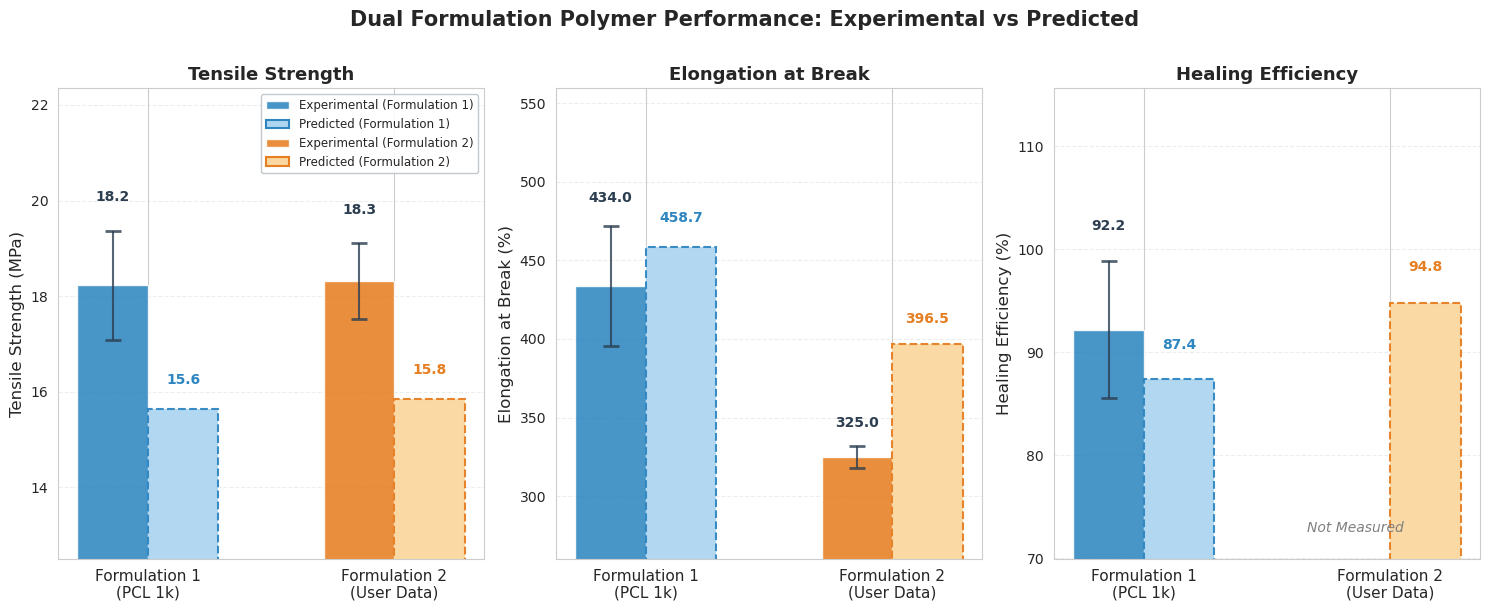

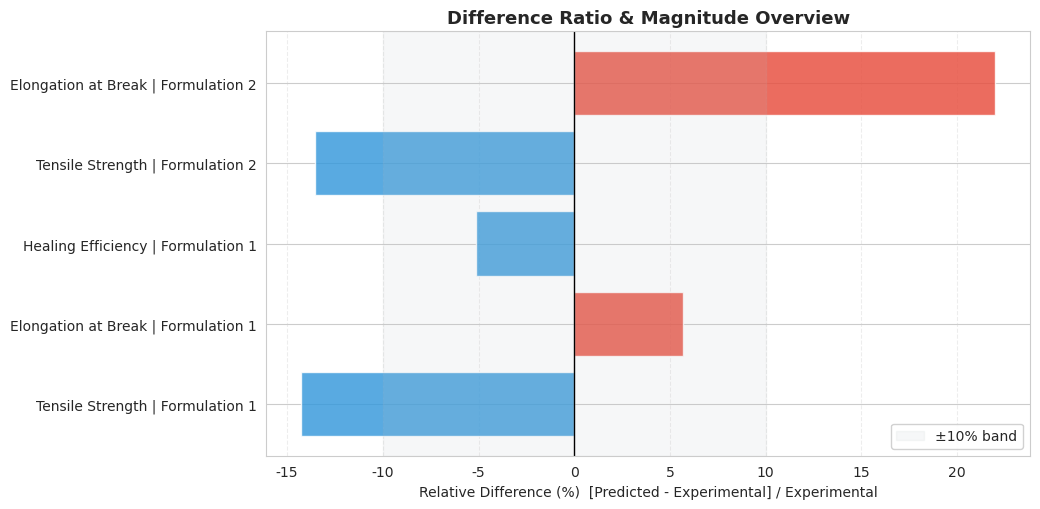

📋 Difference Summary Table (with ratio and magnitude)
  Formulation              Metric Experimental Mean Experimental Error Predicted Absolute Diff Relative Diff (%) Within Exp Error?
Formulation 1    Tensile Strength             18.23               1.14     15.63         -2.60            -14.3%                No
Formulation 1 Elongation at Break            434.00              38.20    458.66        +24.66             +5.7%               Yes
Formulation 1  Healing Efficiency             92.16               6.64     87.43         -4.73             -5.1%               Yes
Formulation 2    Tensile Strength             18.32               0.79     15.84         -2.48            -13.5%                No
Formulation 2 Elongation at Break            325.00               7.00    396.50        +71.50            +22.0%                No
Formulation 2  Healing Efficiency                 -                  -     94.75             -                 -                 -

Average absolute relative di

In [32]:
# ============================================
# 📊 Dual Formulation Performance Comparison
# Main chart + Difference ratio/size + Summary table
# ============================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# --- Font setup (English only) ---
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# --- Formulation data ---
# Formulation 1 (current validated formulation)
Formulation1_Name = 'Formulation 1\n(PCL 1k)'
Formulation1_Experimental_Data = {
    'Tensile Strength': {'mean': 18.23, 'error': 1.14,  'unit': 'MPa'},
    'Elongation at Break': {'mean': 434.00, 'error': 38.20, 'unit': '%'},
    'Healing Efficiency': {'mean': 92.16, 'error': 6.64,  'unit': '%'},
}
Formulation1_Prediction_Data = {
    'Tensile Strength': pred_strength,
    'Elongation at Break': pred_elong,
    'Healing Efficiency': pred_heal_eff,
}

# Formulation 2 (from user-provided measurements)
f2_tensile_vals = np.array([17.57, 19.15, 18.23], dtype=float)
f2_elong_vals = np.array([317.0, 328.0, 330.0], dtype=float)

Formulation2_Name = 'Formulation 2\n(User Data)'
Formulation2_Experimental_Data = {
    'Tensile Strength': {
        'mean': float(np.mean(f2_tensile_vals)),
        'error': float(np.std(f2_tensile_vals, ddof=1)),
        'unit': 'MPa'
    },
    'Elongation at Break': {
        'mean': float(np.mean(f2_elong_vals)),
        'error': float(np.std(f2_elong_vals, ddof=1)),
        'unit': '%'
    },
    'Healing Efficiency': {'mean': None, 'error': None, 'unit': '%'},
}
Formulation2_Prediction_Data = {
    'Tensile Strength': 15.84,
    'Elongation at Break': 396.5,
    'Healing Efficiency': 94.75,
}

# --- Plot configs ---
Metrics_List = ['Tensile Strength', 'Elongation at Break', 'Healing Efficiency']
Units_List = ['MPa', '%', '%']
Color_Formulation1_Exp = '#2E86C1'
Color_Formulation2_Exp = '#E67E22'
Color_Formulation1_Pred = '#AED6F1'
Color_Formulation2_Pred = '#FAD7A0'

# ============================================
# Figure 1: Main grouped subplots (value comparison)
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Dual Formulation Polymer Performance: Experimental vs Predicted',
             fontsize=15, fontweight='bold', y=1.01)

bar_width = 0.2
for col_i, (ax, Metric, Unit) in enumerate(zip(axes, Metrics_List, Units_List)):

    Dataset = [
        (Formulation1_Experimental_Data[Metric]['mean'], Formulation1_Experimental_Data[Metric]['error'],
         Formulation1_Prediction_Data[Metric], Formulation1_Name, Color_Formulation1_Exp, Color_Formulation1_Pred),
        (Formulation2_Experimental_Data[Metric]['mean'], Formulation2_Experimental_Data[Metric]['error'],
         Formulation2_Prediction_Data[Metric], Formulation2_Name, Color_Formulation2_Exp, Color_Formulation2_Pred),
    ]

    x_ticks_positions, x_ticks_labels = [], []

    for idx, (exp_mean, exp_err, pred_val, Formula_Name, Exp_Color, Pred_Color) in enumerate(Dataset):
        x_center = idx * 0.7
        x_exp = x_center - bar_width / 2
        x_pred = x_center + bar_width / 2
        x_ticks_positions.append(x_center)
        x_ticks_labels.append(Formula_Name)

        if exp_mean is not None:
            ax.bar(x_exp, exp_mean, width=bar_width, color=Exp_Color, alpha=0.88,
                   label='Experimental' if idx == 0 else '')
            ax.errorbar(x_exp, exp_mean, yerr=exp_err,
                        fmt='none', capsize=6, capthick=2, color='#2C3E50', alpha=0.8)
            ax.text(x_exp, exp_mean + exp_err + exp_mean * 0.03,
                    f'{exp_mean:.1f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color='#2C3E50')
        else:
            ax.text(x_exp, 0.05, 'Not Measured', ha='center', va='bottom',
                    fontsize=10, color='gray', style='italic', transform=ax.get_xaxis_transform())

        if pred_val is not None:
            ax.bar(x_pred, pred_val, width=bar_width, color=Pred_Color, alpha=0.95,
                   edgecolor=Exp_Color, linewidth=1.5,
                   label='Predicted' if idx == 0 else '', linestyle='--')
            ax.text(x_pred, pred_val * 1.03,
                    f'{pred_val:.1f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=Exp_Color)
        else:
            ax.text(x_pred, 0.05, 'Not Predicted', ha='center', va='bottom',
                    fontsize=10, color='gray', style='italic', transform=ax.get_xaxis_transform())

    ax.set_xticks(x_ticks_positions)
    ax.set_xticklabels(x_ticks_labels, fontsize=11)
    ax.set_ylabel(f'{Metric} ({Unit})', fontsize=12)
    ax.set_title(Metric, fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    y_vals = [v for v in [
        Formulation1_Experimental_Data[Metric]['mean'], Formulation1_Prediction_Data[Metric],
        Formulation2_Experimental_Data[Metric]['mean'], Formulation2_Prediction_Data[Metric]
    ] if v is not None]
    if y_vals:
        ax.set_ylim(min(y_vals) * 0.80, max(y_vals) * 1.22)

    if col_i == 0:
        legend_elements = [
            Patch(facecolor=Color_Formulation1_Exp, alpha=0.88, label='Experimental (Formulation 1)'),
            Patch(facecolor=Color_Formulation1_Pred, edgecolor=Color_Formulation1_Exp, linewidth=1.5, label='Predicted (Formulation 1)'),
            Patch(facecolor=Color_Formulation2_Exp, alpha=0.88, label='Experimental (Formulation 2)'),
            Patch(facecolor=Color_Formulation2_Pred, edgecolor=Color_Formulation2_Exp, linewidth=1.5, label='Predicted (Formulation 2)'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8.5,
                  framealpha=0.9, edgecolor='#BDC3C7')

Figure_Main = fig
plt.tight_layout()
plt.show()

# ============================================
# Build quantitative difference table
# ============================================
records = []
for formulation_name, exp_data, pred_data in [
    ('Formulation 1', Formulation1_Experimental_Data, Formulation1_Prediction_Data),
    ('Formulation 2', Formulation2_Experimental_Data, Formulation2_Prediction_Data),
]:
    for metric in Metrics_List:
        exp_mean = exp_data[metric]['mean']
        exp_err = exp_data[metric]['error']
        pred_val = pred_data[metric]
        unit = exp_data[metric]['unit']

        if (exp_mean is not None) and (pred_val is not None):
            abs_diff = pred_val - exp_mean
            rel_diff_pct = abs_diff / exp_mean * 100 if exp_mean != 0 else np.nan
            within_exp_unc = abs(abs_diff) <= exp_err if exp_err is not None else np.nan
        else:
            abs_diff = np.nan
            rel_diff_pct = np.nan
            within_exp_unc = np.nan

        records.append({
            'Formulation': formulation_name,
            'Metric': metric,
            'Unit': unit,
            'Experimental Mean': exp_mean,
            'Experimental Error': exp_err,
            'Predicted': pred_val,
            'Absolute Diff': abs_diff,
            'Relative Diff (%)': rel_diff_pct,
            'Within Exp Error?': within_exp_unc,
        })

Diff_Table = pd.DataFrame(records)

# ============================================
# Figure 2: Difference ratio/size view
# ============================================
plot_df = Diff_Table.dropna(subset=['Relative Diff (%)']).copy()

if len(plot_df) > 0:
    fig2, ax2 = plt.subplots(figsize=(10.5, 5.2))

    y_labels = [f"{m} | {f}" for m, f in zip(plot_df['Metric'], plot_df['Formulation'])]
    y_pos = np.arange(len(plot_df))
    rel_vals = plot_df['Relative Diff (%)'].values

    colors = ['#E74C3C' if v > 0 else '#3498DB' for v in rel_vals]
    ax2.barh(y_pos, rel_vals, color=colors, alpha=0.82)

    ax2.axvline(0, color='black', linewidth=1.0)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(y_labels)
    ax2.set_xlabel('Relative Difference (%)  [Predicted - Experimental] / Experimental')
    ax2.set_title('Difference Ratio & Magnitude Overview', fontsize=13, fontweight='bold')
    ax2.grid(axis='x', linestyle='--', alpha=0.35)

    ax2.axvspan(-10, 10, color='#BDC3C7', alpha=0.12, label='±10% band')
    ax2.legend(loc='lower right', framealpha=0.9)

    Figure_Diff = fig2
    plt.tight_layout()
    plt.show()
else:
    print('No paired experimental/predicted data available yet for difference-ratio plotting.')

# ============================================
# Print summary table
# ============================================
display_cols = [
    'Formulation', 'Metric', 'Experimental Mean', 'Experimental Error',
    'Predicted', 'Absolute Diff', 'Relative Diff (%)', 'Within Exp Error?'
]

Summary_Table = Diff_Table[display_cols].copy()
Summary_Table['Experimental Mean'] = Summary_Table['Experimental Mean'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
Summary_Table['Experimental Error'] = Summary_Table['Experimental Error'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
Summary_Table['Predicted'] = Summary_Table['Predicted'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
Summary_Table['Absolute Diff'] = Summary_Table['Absolute Diff'].map(lambda x: f'{x:+.2f}' if pd.notna(x) else '-')
Summary_Table['Relative Diff (%)'] = Summary_Table['Relative Diff (%)'].map(lambda x: f'{x:+.1f}%' if pd.notna(x) else '-')
Summary_Table['Within Exp Error?'] = Summary_Table['Within Exp Error?'].map(
    lambda x: 'Yes' if x is True else ('No' if x is False else '-')
)

print('=' * 95)
print('📋 Difference Summary Table (with ratio and magnitude)')
print('=' * 95)
print(Summary_Table.to_string(index=False))

paired_n = len(plot_df)
if paired_n > 0:
    mape_like = np.mean(np.abs(plot_df['Relative Diff (%)']))
    print(f'\nAverage absolute relative difference across available pairs: {mape_like:.2f}%')

print('\nFormulation 2 tensile replicates:', f2_tensile_vals.tolist())
print('Formulation 2 elongation replicates:', f2_elong_vals.tolist())
print('Tip: Healing experimental data for Formulation 2 can be filled later.')

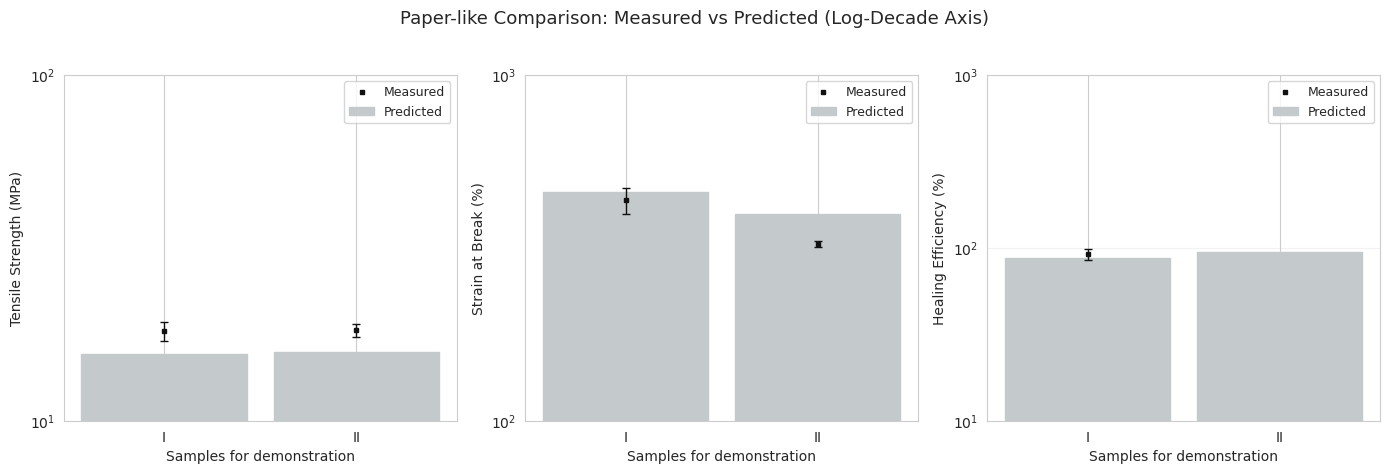

Scale mode: LOG scale (decade ticks only)
Y-axis labels are now shown as 10^n only, with visible axis tick marks.


In [31]:
# ============================================
# 📈 Paper-like plot style (Predicted bar + Measured marker)
# Log y-axis with decade ticks only (10^1, 10^2, 10^3 ...)
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

# If the previous comparison cell has been run, these dicts should exist:
# Formulation1_Experimental_Data, Formulation1_Prediction_Data
# Formulation2_Experimental_Data, Formulation2_Prediction_Data

use_log_scale = True

metrics = ['Tensile Strength', 'Elongation at Break', 'Healing Efficiency']
ylabels = ['Tensile Strength (MPa)', 'Strain at Break (%)', 'Healing Efficiency (%)']

sample_labels = ['I', 'II']
x = np.arange(len(sample_labels))

predicted_color = '#C4C9CC'
measured_color = '#111111'

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    ax = axes[i]

    pred_vals = np.array([
        Formulation1_Prediction_Data[metric],
        Formulation2_Prediction_Data[metric],
    ], dtype=float)

    exp_vals = np.array([
        Formulation1_Experimental_Data[metric]['mean'] if Formulation1_Experimental_Data[metric]['mean'] is not None else np.nan,
        Formulation2_Experimental_Data[metric]['mean'] if Formulation2_Experimental_Data[metric]['mean'] is not None else np.nan,
    ], dtype=float)

    exp_errs = np.array([
        Formulation1_Experimental_Data[metric]['error'] if Formulation1_Experimental_Data[metric]['error'] is not None else np.nan,
        Formulation2_Experimental_Data[metric]['error'] if Formulation2_Experimental_Data[metric]['error'] is not None else np.nan,
    ], dtype=float)

    # Predicted bars
    ax.bar(x, pred_vals, width=0.86, color=predicted_color, edgecolor=predicted_color, zorder=1)

    # Measured markers with error bars (only where available)
    for xi, m, e in zip(x, exp_vals, exp_errs):
        if np.isfinite(m):
            if np.isfinite(e):
                ax.errorbar(xi, m, yerr=e, fmt='s', color=measured_color,
                            markersize=3.5, capsize=3, linewidth=1.0, zorder=3)
            else:
                ax.plot(xi, m, 's', color=measured_color, markersize=3.5, zorder=3)

    finite_all = np.concatenate([
        pred_vals[np.isfinite(pred_vals)],
        exp_vals[np.isfinite(exp_vals)]
    ])

    if use_log_scale:
        positive_vals = finite_all[finite_all > 0]
        if len(positive_vals) > 0:
            low_decade = 10 ** np.floor(np.log10(np.min(positive_vals)))
            high_decade = 10 ** np.ceil(np.log10(np.max(positive_vals) * 1.15))
            if low_decade == high_decade:
                high_decade = low_decade * 10

            ax.set_yscale('log')
            ax.set_ylim(low_decade, high_decade)

            # Only show decade ticks: 10^1, 10^2, 10^3 ...
            ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=12))
            ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
            ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=()))
            ax.yaxis.set_minor_formatter(NullFormatter())
    else:
        y_min = np.min(finite_all) * 0.6
        y_max = np.max(finite_all) * 1.4
        ax.set_ylim(y_min, y_max)

    ax.set_xticks(x)
    ax.set_xticklabels(sample_labels)
    ax.set_xlabel('Samples for demonstration')
    ax.set_ylabel(ylabel)

    # Axis tick lines (what you requested)
    ax.tick_params(axis='both', which='major', direction='inout', length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)

    # Grid lines aligned to major ticks
    ax.grid(axis='y', which='major', linestyle='-', alpha=0.25)

# Common legend (paper-like)
legend_handles = [
    Line2D([0], [0], marker='s', linestyle='None', color=measured_color, markersize=3.5, label='Measured'),
    Patch(facecolor=predicted_color, edgecolor=predicted_color, label='Predicted'),
]
for ax in axes:
    ax.legend(handles=legend_handles, loc='upper right', frameon=True, fontsize=9)

fig.suptitle('Paper-like Comparison: Measured vs Predicted (Log-Decade Axis)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Scale mode:', 'LOG scale (decade ticks only)')
print('Y-axis labels are now shown as 10^n only, with visible axis tick marks.')

# 🔍 特征体系问题诊断与修正建议

> 以下诊断基于 `data_washiong_1.8_useful.py` 的特征工程代码、`Final_Features_Ultimate_all_deletion.csv` 训练集 (85条)、以及虚拟配方库生成逻辑的交叉核查。

In [ ]:
# ============================================
# 🎯 基于软段 10 mmol 的三个最优 trade-off 配方
# 直接输出可实验投料（按当前虚拟库最优候选）
# ============================================
import pandas as pd
import numpy as np
import re

SOFT_SEGMENT_MMOL = 10.0

MW_MAP = {
    ('PTMG', 1000): 1000.0,
    ('PTMG', 2000): 2000.0,
    ('PPG', 1000): 1000.0,
    ('PPG', 2000): 2000.0,
    ('PCL', 1000): 1000.0,
    ('PCL', 2000): 2000.0,
    ('PBA', 1000): 1000.0,
    ('PBA', 2000): 2000.0,
    'IPDI': 222.28,
    'HDI': 168.20,
    'MDI': 250.25,
    'TDI': 174.16,
    'FDM': 128.13,
    'FA': 98.10,
    'FAm': 97.12,
    'BMI': 358.35,
}

# KC 主链体系在你已有示例中对应固定拆分：FDM / FA / BMI = 1.281 / 0.491 / 2.688 (mass ratio)
KC_MAIN_SPLIT = {
    'FDM': 1.281 / (1.281 + 0.491 + 2.688),
    'FA': 0.491 / (1.281 + 0.491 + 2.688),
    'BMI': 2.688 / (1.281 + 0.491 + 2.688),
}


def parse_recipe_name(recipe_name):
    match = re.match(r'([A-Za-z]+)(\d+)_([A-Za-z]+)_([A-Za-z]+)\((Main|Side)\)', recipe_name)
    if not match:
        return None
    polyol, soft_mw, iso, da, topo = match.groups()
    return {
        'polyol': polyol,
        'soft_mw': int(soft_mw),
        'iso': iso,
        'da': da,
        'topology': '主链' if topo == 'Main' else '侧链'
    }


def mmol_to_grams(mmol, mw):
    return mmol * mw / 1000.0


def build_experimental_recipe(row):
    info = parse_recipe_name(row['Recipe_Name'])
    if info is None:
        return None

    soft_mw_value = MW_MAP[(info['polyol'], info['soft_mw'])]
    iso_mw_value = MW_MAP[info['iso']]

    soft_g = mmol_to_grams(SOFT_SEGMENT_MMOL, soft_mw_value)
    solid_total_g = soft_g / row['X1_Soft_Content']

    iso_g = solid_total_g * row['X3_Hard_Content']
    da_total_g = solid_total_g * row['X2_DA_Content']
    crosslink_g = solid_total_g * row['X5_Add_Crosslink']

    fdm_g = np.nan
    fa_g = np.nan
    fam_g = np.nan
    bmi_g = np.nan

    if info['da'] == 'KC' and info['topology'] == '主链':
        fdm_g = da_total_g * KC_MAIN_SPLIT['FDM']
        fa_g = da_total_g * KC_MAIN_SPLIT['FA']
        bmi_g = da_total_g * KC_MAIN_SPLIT['BMI']

    result = {
        '配方名称': row['Recipe_Name'],
        '软段种类': f"{info['polyol']}{info['soft_mw']}",
        '异氰酸酯种类': info['iso'],
        'DA种类': info['da'],
        '拓扑': info['topology'],
        '软段 mmol': SOFT_SEGMENT_MMOL,
        '软段 g': round(soft_g, 3),
        '异氰酸酯 mmol': round(iso_g / iso_mw_value * 1000.0, 2),
        '异氰酸酯 g': round(iso_g, 3),
        'FDM mmol': round(fdm_g / MW_MAP['FDM'] * 1000.0, 2) if pd.notna(fdm_g) else np.nan,
        'FDM g': round(fdm_g, 3) if pd.notna(fdm_g) else np.nan,
        'FA mmol': round(fa_g / MW_MAP['FA'] * 1000.0, 2) if pd.notna(fa_g) else np.nan,
        'FA g': round(fa_g, 3) if pd.notna(fa_g) else np.nan,
        'FAm mmol': round(fam_g / MW_MAP['FAm'] * 1000.0, 2) if pd.notna(fam_g) else np.nan,
        'FAm g': round(fam_g, 3) if pd.notna(fam_g) else np.nan,
        'BMI mmol': round(bmi_g / MW_MAP['BMI'] * 1000.0, 2) if pd.notna(bmi_g) else np.nan,
        'BMI g': round(bmi_g, 3) if pd.notna(bmi_g) else np.nan,
        '额外交联剂 g': round(crosslink_g, 3),
        'X1_Soft_Content': round(row['X1_Soft_Content'], 4),
        'X2_DA_Content': round(row['X2_DA_Content'], 4),
        'X3_Hard_Content': round(row['X3_Hard_Content'], 4),
        'X4_R_Ratio': round(row['X4_R_Ratio'], 4),
        'X5_Add_Crosslink': round(row['X5_Add_Crosslink'], 4),
        '预测强度(MPa)': round(row['Pred_Strength'], 2),
        '预测伸长率(%)': round(row['Pred_Elongation'], 2),
        '预测愈合率(%)': round(row['Pred_Healing'], 2),
    }
    return result


candidate_pool = df_virtual_lib.copy()
candidate_pool = candidate_pool[
    (candidate_pool['Soft_Mw'] == 2000) &
    (candidate_pool['Network_Topology'] == 0) &
    (candidate_pool['Pred_Elongation'] >= 500)
].copy()

if len(candidate_pool) == 0:
    raise ValueError('没有找到满足 Soft_Mw=2000、主链、伸长率>=500 的候选配方。')

for col in ['Pred_Strength', 'Pred_Healing', 'Pred_Elongation']:
    candidate_pool[f'{col}_norm'] = (
        candidate_pool[col] - candidate_pool[col].min()
    ) / (candidate_pool[col].max() - candidate_pool[col].min() + 1e-9)

candidate_pool['score_strength_balanced'] = (
    0.50 * candidate_pool['Pred_Strength_norm'] +
    0.25 * candidate_pool['Pred_Healing_norm'] +
    0.25 * candidate_pool['Pred_Elongation_norm']
)
candidate_pool['score_healing_balanced'] = (
    0.25 * candidate_pool['Pred_Strength_norm'] +
    0.50 * candidate_pool['Pred_Healing_norm'] +
    0.25 * candidate_pool['Pred_Elongation_norm']
)
candidate_pool['score_overall_balanced'] = (
    0.34 * candidate_pool['Pred_Strength_norm'] +
    0.33 * candidate_pool['Pred_Healing_norm'] +
    0.33 * candidate_pool['Pred_Elongation_norm']
)

selected_rows = []
used_recipe_names = set()

for label, score_col in [
    ('配方A-高强度优先型', 'score_strength_balanced'),
    ('配方B-综合平衡型(PCL)', 'score_healing_balanced'),
    ('配方C-综合平衡型(PBA)', 'score_overall_balanced'),
]:
    ranked = candidate_pool.sort_values(score_col, ascending=False)
    chosen = None
    for _, row in ranked.iterrows():
        if row['Recipe_Name'] not in used_recipe_names:
            chosen = row
            used_recipe_names.add(row['Recipe_Name'])
            break
    if chosen is not None:
        recipe_detail = build_experimental_recipe(chosen)
        if recipe_detail is not None:
            recipe_detail['策略定位'] = label
            selected_rows.append(recipe_detail)

tradeoff_df = pd.DataFrame(selected_rows)

print('=' * 120)
print('🎯 基于软段 10 mmol 的三个最优 trade-off 配方')
print('=' * 120)
print('说明：当前候选库里，高强度与高伸长率最优解集中在 2000 + MDI + KC(主链) 体系，预测愈合率上限约为 63–65%。')

for _, row in tradeoff_df.iterrows():
    print(f"\n【{row['策略定位']}】")
    print(f"配方类型: {row['配方名称']}")
    print(f"质量分数: X1={row['X1_Soft_Content']:.4f}, X2={row['X2_DA_Content']:.4f}, X3={row['X3_Hard_Content']:.4f}, X4={row['X4_R_Ratio']:.4f}, X5={row['X5_Add_Crosslink']:.4f}")
    print('--- 直接投料建议 ---')
    print(f"软段: {row['软段 mmol']:.2f} mmol, {row['软段 g']:.3f} g")
    print(f"{row['异氰酸酯种类']}: {row['异氰酸酯 mmol']:.2f} mmol, {row['异氰酸酯 g']:.3f} g")
    if pd.notna(row['FDM mmol']):
        print(f"FDM: {row['FDM mmol']:.2f} mmol, {row['FDM g']:.3f} g")
    if pd.notna(row['FA mmol']):
        print(f"FA: {row['FA mmol']:.2f} mmol, {row['FA g']:.3f} g")
    if pd.notna(row['FAm mmol']):
        print(f"FAm: {row['FAm mmol']:.2f} mmol, {row['FAm g']:.3f} g")
    if pd.notna(row['BMI mmol']):
        print(f"BMI: {row['BMI mmol']:.2f} mmol, {row['BMI g']:.3f} g")
    if row['额外交联剂 g'] > 0:
        print(f"额外交联剂: {row['额外交联剂 g']:.3f} g")
    print('--- 预测性能 ---')
    print(f"强度: {row['预测强度(MPa)']:.2f} MPa | 伸长率: {row['预测伸长率(%)']:.2f}% | 愈合率: {row['预测愈合率(%)']:.2f}%")

save_cols = [
    '策略定位', '配方名称', '软段种类', '异氰酸酯种类', 'DA种类', '拓扑',
    '软段 mmol', '软段 g', '异氰酸酯 mmol', '异氰酸酯 g',
    'FDM mmol', 'FDM g', 'FA mmol', 'FA g', 'FAm mmol', 'FAm g', 'BMI mmol', 'BMI g',
    '额外交联剂 g',
    'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink',
    '预测强度(MPa)', '预测伸长率(%)', '预测愈合率(%)'
]

tradeoff_df[save_cols].to_csv('Top3_Tradeoff_Recipes_10mmol.csv', index=False)
print('\n✅ 已保存到 Top3_Tradeoff_Recipes_10mmol.csv')

tradeoff_df[save_cols]